In [5]:
#Importa módulos y crear variables
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


dir = './datos/calibracion/'
files = os.listdir(dir)

def lineal(x, a, b):
    return x * a + b

In [6]:
# Estilos 
plt.rcParams.update({
    "font.family": "CMU Serif",
    "font.weight":'medium'
})

def python_style_st(x = 'ejex', y = 'ejey', titulo = None, both = True):
    # sns.set_theme()
    plt.grid(True, linestyle='--', alpha=0.8)
    plt.xlabel(x, fontsize = 15)
    plt.ylabel(y, fontsize = 15)
    if both:
        plt.tick_params(axis="both", direction = "in")
    else:
        plt.tick_params(direction = "in")
    plt.title(titulo)
    plt.xticks(fontsize = 13)
    plt.yticks(fontsize = 13)


def python_style_end():
    plt.tight_layout()

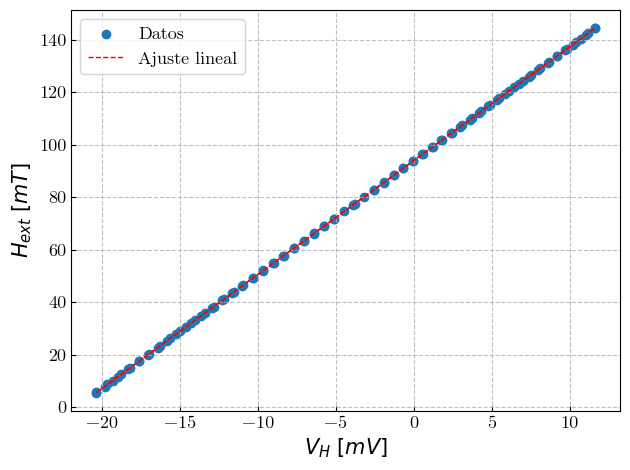

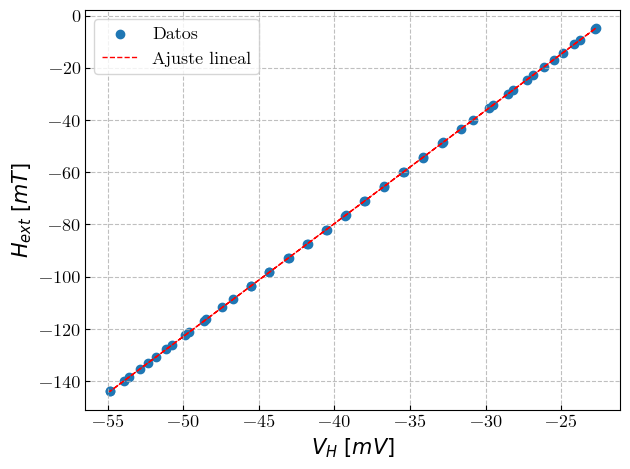

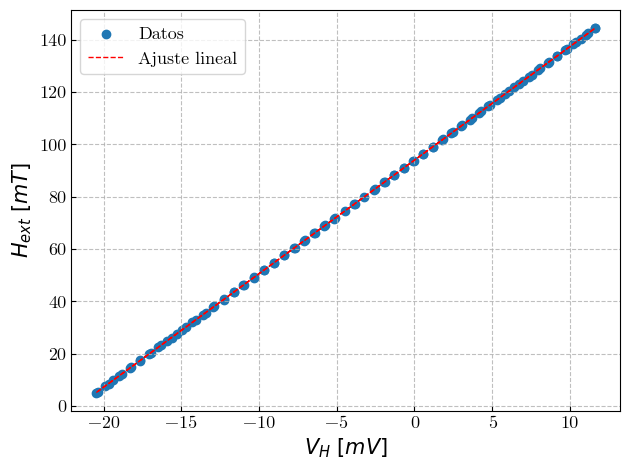

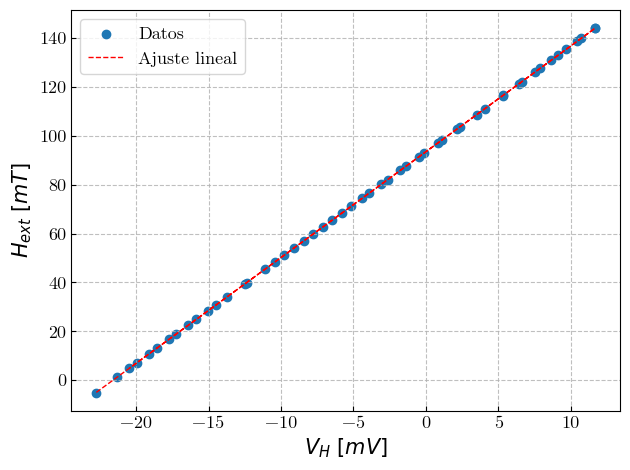

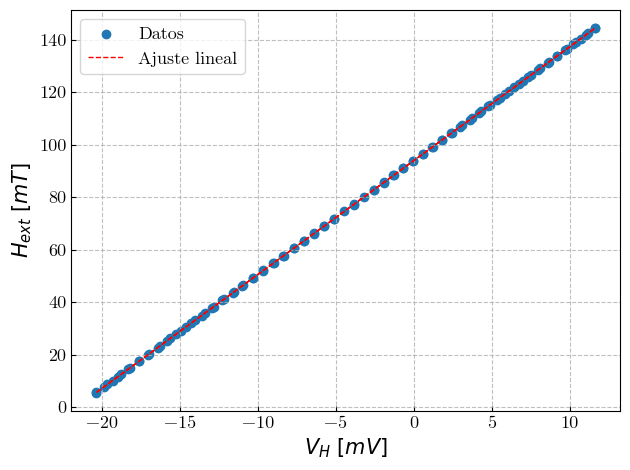

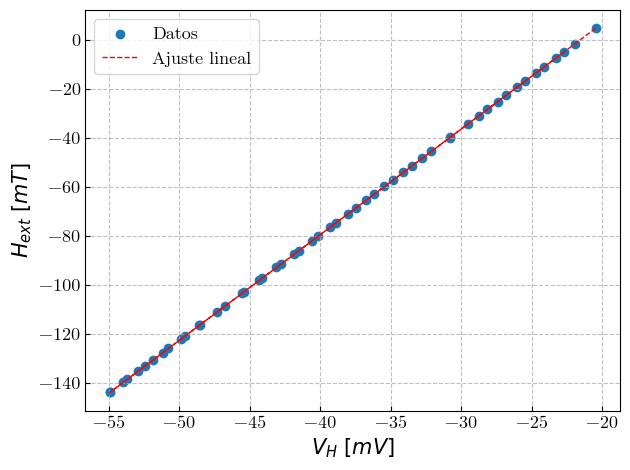

In [ ]:
pendientes = np.empty(0)
err_pendientes = np.empty(0)
coord_origenes = np.empty(0)
err_coord_origenes = np.empty(0)

counter = 1

for file in files:
    datos = pd.read_csv(dir + file, sep = '\t')

    #Corriente y tension a 3 decimales
    datos['Corriente (A)'] = np.round(datos['Corriente (A)'], 3)

    if "negat" in file:
        datos['Corriente (A)'] = -datos['Corriente (A)']

    # plt.scatter(datos['Corriente (A)'], datos['Campo_Gaussimetro (mT)'])
    x = datos['Voltaje_Rigol (V)'] * 1000 # mV
    y = datos['Campo_Gaussimetro (T)'] * 1000 #mT

    aju, cov = curve_fit(lineal, x, y)
    err = np.sqrt(np.diag(cov))
    
    a = aju[0]
    erra = err[0]

    b = aju[1]
    errb = err[1]

    pendientes = np.append(pendientes, a)
    err_pendientes = np.append(err_pendientes, erra)

    coord_origenes = np.append(coord_origenes, b)
    err_coord_origenes = np.append(err_coord_origenes, errb)

    python_style_st(y = r'$H_{ext} \ [mT]$', x = r'$V_{H} \ [mV]$')
    plt.scatter(x, y, marker = 'o', label = 'Datos')
    plt.plot(x, a * x + b, label = 'Ajuste lineal', linestyle = '--', color = 'red', linewidth = 1)
    plt.legend(fontsize = 13)



    python_style_end()
    plt.show()
    

In [21]:
pen = np.average(pendientes)
err_pen = np.std(pendientes)

coord = np.average(coord_origenes)
err_coord = np.std(coord_origenes)

print(pen, err_pen)
print(coord, err_coord)

4.331286718961333 0.006123006022432455
93.68764551838969 0.24506874727374084
